# Task 2: Exploratory Data Analysis (EDA) - Bookstore Dataset
**Internship:** CodeAlpha Data Analytics Internship  
**Domain:** Exploratory Data Analysis (EDA)

---

## 1. Project Objective & Core Questions
Analysis shuru karne se pehle business aur data goals set kiye gaye:
1. **Price Distribution:** Books ki average, minimum aur maximum price range kya hai?
2. **Category Dominance:** Kis category mein sabse zyada inventory hai aur kaunsi category sabse expensive hai?
3. **Rating Analysis:** Customer ratings ka pattern kaisa hai?
4. **Hypothesis Testing:** Kya price aur customer rating ke beech direct correlation hai?
5. **Inventory Health:** Total available stock kitna hai aur kya stock rating par depend karta hai?

In [12]:
import pandas as pd

# CSV file load करना
df = pd.read_csv("books_dataset.csv")

# Dataset की पहली 5 rows देखना
df.head()

,title,price,rating,availability,category,upc,reviews,stock
0,A Light in the Attic,51.77,3,In stock (22 available),Poetry,a897fe39b1053632,0,22
1,Tipping the Velvet,53.74,1,In stock (20 available),Historical Fiction,90fa61229261140a,0,20
2,Soumission,50.10,1,In stock (20 available),Fiction,6957f44c3847a760,0,20
3,Sharp Objects,47.82,4,In stock (20 available),Mystery,e00eb4fd7b871a48,0,20
4,Sapiens: A Brief History of Humankind,54.23,5,In stock (20 available),History,4165285e1663650f,0,20


In [2]:
print("Shape:", df.shape)

Shape: (20, 8)


In [3]:
print("Columns:")
print(df.columns)

Columns:
Index(['title', 'price', 'rating', 'availability', 'category', 'upc',
       'reviews', 'stock'],
      dtype='object')


## 2. Data Structure & Type Inspection
Is step mein hum data types, missing values aur general statistical properties verify karenge.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         20 non-null     object 
 1   price         20 non-null     float64
 2   rating        20 non-null     int64  
 3   availability  20 non-null     object 
 4   category      20 non-null     object 
 5   upc           20 non-null     object 
 6   reviews       20 non-null     int64  
 7   stock         20 non-null     int64  
dtypes: float64(1), int64(3), object(4)
memory usage: 1.4+ KB


In [5]:
df.describe()

,price,rating,reviews,stock
count,20.000000,20.000000,20.0,20.00000
mean,38.048500,2.850000,0.0,19.35000
std,15.135231,1.565248,0.0,0.74516
min,13.990000,1.000000,0.0,19.00000
25%,22.637500,1.000000,0.0,19.00000
50%,41.380000,3.000000,0.0,19.00000
75%,51.865000,4.000000,0.0,19.25000
max,57.250000,5.000000,0.0,22.00000


In [13]:
# Missing values check
print("\nMissing values per column:\n", df.isnull().sum())


Missing values per column:
 title           0
price           0
rating          0
availability    0
category        0
upc             0
reviews         0
stock           0
dtype: int64


## 3. Trends, Patterns & Anomalies Identification
Summary statistics aur category-wise grouping ke zariye data ke main patterns check karna.

In [14]:
# 1. Price metrics
avg_price = df['price'].mean()
min_price = df['price'].min()
max_price = df['price'].max()

print(f"Average Price: £{avg_price:.2f}")
print(f"Price Range: £{min_price:.2f} to £{max_price:.2f}")

# 2. Category breakdown
cat_analysis = df.groupby('category').agg(
    Book_Count=('title', 'count'),
    Avg_Price=('price', 'mean')
).sort_values(by='Book_Count', ascending=False)

print("\nCategory Performance:\n", cat_analysis)

# 3. Rating distribution
print("\nRating Distribution:\n", df['rating'].value_counts().sort_index())

Average Price: £38.05
Price Range: £13.99 to £57.25

Category Performance:
                     Book_Count  Avg_Price
category                                 
Poetry                       4  37.115000
Default                      3  18.173333
Music                        2  46.135000
Young Adult                  2  20.055000
Business                     1  33.340000
Fiction                      1  50.100000
Historical Fiction           1  53.740000
History                      1  54.230000
Mystery                      1  47.820000
Politics                     1  51.330000
Science Fiction              1  37.590000
Sequential Art               1  52.290000
Travel                       1  45.170000

Rating Distribution:
 rating
1    6
2    3
3    3
4    4
5    4
Name: count, dtype: int64


## 4. Hypothesis Testing & Visual Validation

### Hypotheses:
- **H1:** "Higher priced books receive higher customer ratings." (Price & Rating have a positive correlation).
- **H2:** "Available stock is evenly distributed across all rating tiers."

Correlation Matrix:
            price    rating     stock
price   1.000000 -0.075857  0.442684
rating -0.075857  1.000000  0.002256
stock   0.442684  0.002256  1.000000


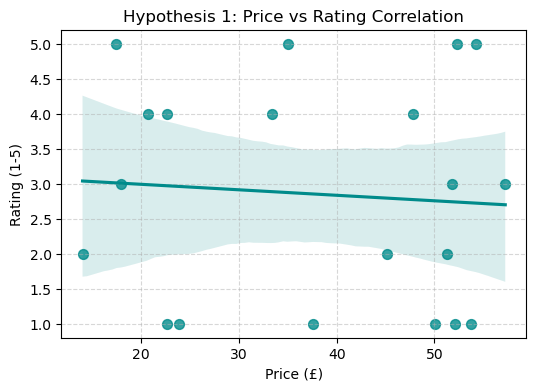

C:\Users\hp\AppData\Local\Temp\ipykernel_2840\352516035.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='rating', y='stock', data=df, palette='Set2')


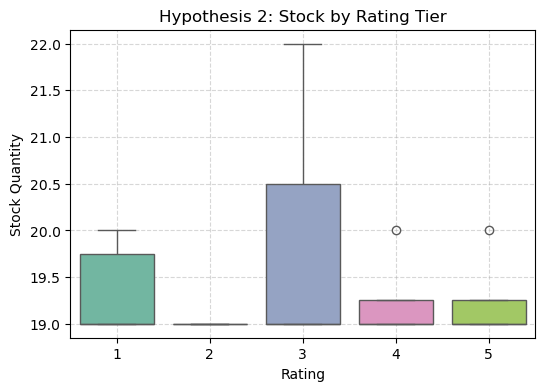

In [15]:
# Correlation Matrix
corr = df[['price', 'rating', 'stock']].corr()
print("Correlation Matrix:\n", corr)

# Visualizing H1: Price vs Rating
plt.figure(figsize=(6, 4))
sns.regplot(x='price', y='rating', data=df, color='darkcyan', scatter_kws={'s': 50})
plt.title("Hypothesis 1: Price vs Rating Correlation")
plt.xlabel("Price (£)")
plt.ylabel("Rating (1-5)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# Visualizing H2: Rating vs Stock
plt.figure(figsize=(6, 4))
sns.boxplot(x='rating', y='stock', data=df, palette='Set2')
plt.title("Hypothesis 2: Stock by Rating Tier")
plt.xlabel("Rating")
plt.ylabel("Stock Quantity")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

## 5. Potential Data Quality Issues & Limitations
Aage ke analysis (Visualizations & Sentiment Analysis) ke liye data issues identify kiye gaye:

In [16]:
# Zero variance check
zero_variance = [col for col in df.columns if df[col].nunique() == 1]
print("Zero Variance Columns:", zero_variance)

# Ambiguous category count
print("Books tagged as 'Default':", (df['category'] == 'Default').sum())

# Total dataset rows
print("Total records available:", len(df))

Zero Variance Columns: ['reviews']
Books tagged as 'Default': 3
Total records available: 20
